In [5]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os

project_path = "/content/drive/MyDrive/Fraud_Detection_Project"

os.makedirs(project_path, exist_ok=True)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/Fraud_Detection_Project


In [10]:
# STEP 1: INSTALL & IMPORT LIBRARIES

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [11]:
#STEP 2: Load the dataset
data_path = os.path.join(project_path, "creditcard_2023.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['Class'].value_counts()}")

Dataset shape: (568630, 31)
Class distribution:
Class
0    284315
1    284315
Name: count, dtype: int64


In [12]:
# STEP 3: PREPARE FEATURES & TARGET
X = df.drop(['id', 'Class'], axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (568630, 29)
Target shape: (568630,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (454904, 29)
Test set: (113726, 29)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [15]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9991 - loss: 0.0041 - precision: 0.9988 - recall: 0.9995 - val_accuracy: 0.9996 - val_loss: 0.0018 - val_precision: 0.9993 - val_recall: 1.0000
Epoch 2/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9990 - loss: 0.0050 - precision: 0.9985 - recall: 0.9994 - val_accuracy: 0.9996 - val_loss: 0.0021 - val_precision: 0.9993 - val_recall: 1.0000
Epoch 3/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.9989 - loss: 0.0049 - precision: 0.9985 - recall: 0.9994 - val_accuracy: 0.9996 - val_loss: 0.0023 - val_precision: 0.9993 - val_recall: 1.0000
Epoch 4/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9988 - loss: 0.0048 - precision: 0.9984 - recall: 0.9993 - val_accuracy: 0.9996 - val_loss: 0.0019 - val_precision: 0.9993 - val_recall: 1.0000
Epoch 5/50
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9989 - loss: 0.0049 - precision: 0.9983 - recall: 0.9995 - val_accura

In [18]:

# STEP 8: EVALUATE MODEL


# Predict probabilities
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

3554/3554 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

=== MODEL PERFORMANCE ===
Accuracy: 0.9996
Precision: 0.9992
Recall: 1.0000
F1-Score: 0.9996

Confusion Matrix:
[[56815    48]
 [    0 56863]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



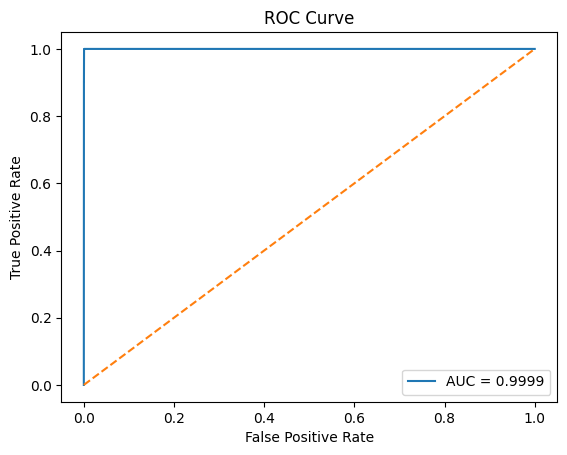

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
# Predict probabilities
y_pred_prob = model.predict(X_test_scaled)

# Apply threshold (change 0.5 → 0.3 or 0.9)
threshold = 0.3
y_pred = (y_pred_prob > threshold).astype(int)

# Evaluate
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

3554/3554 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Recall: 1.0
Precision: 0.9990863568479311
F1-Score: 0.9995429696426374
Accuracy: 0.9995427606703832


In [25]:
# Predict probabilities
y_pred_prob = model.predict(X_test_scaled)

# Apply threshold (change 0.5 → 0.3 or 0.9)
threshold = 0.9
y_pred = (y_pred_prob > threshold).astype(int)

# Evaluate
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

3554/3554 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Recall: 0.9999648277438756
Precision: 0.9993672777123574
F1-Score: 0.9996659634317863
Accuracy: 0.9996658635668185


3554/3554 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
=== METRICS AT DIFFERENT THRESHOLDS ===

Threshold: 0.3
Recall: 1.0
Precision: 0.9990863568479311
F1-Score: 0.9995429696426374
Accuracy: 0.9995427606703832

Threshold: 0.5
Recall: 1.0
Precision: 0.9991565778144823
F1-Score: 0.9995781109919666
Accuracy: 0.9995779329265075

Threshold: 0.7
Recall: 1.0
Precision: 0.9992619277743607
F1-Score: 0.9996308276492512
Accuracy: 0.9996306913106942

Threshold: 0.9
Recall: 0.9999648277438756
Precision: 0.9993672777123574
F1-Score: 0.9996659634317863
Accuracy: 0.9996658635668185


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


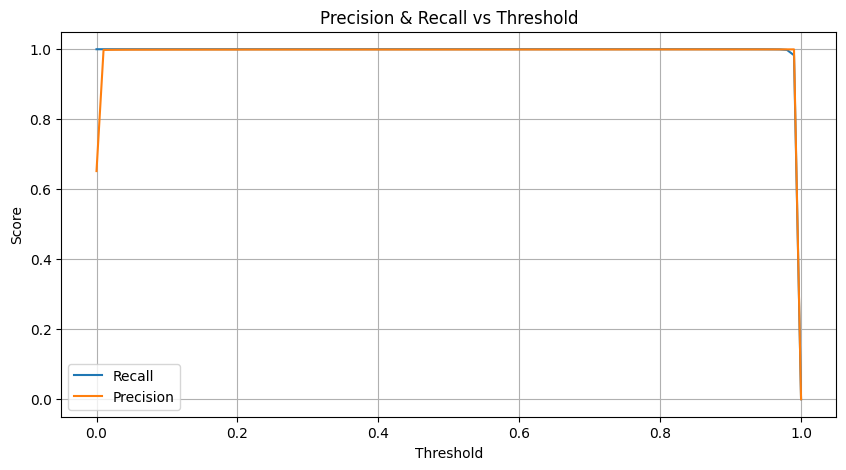

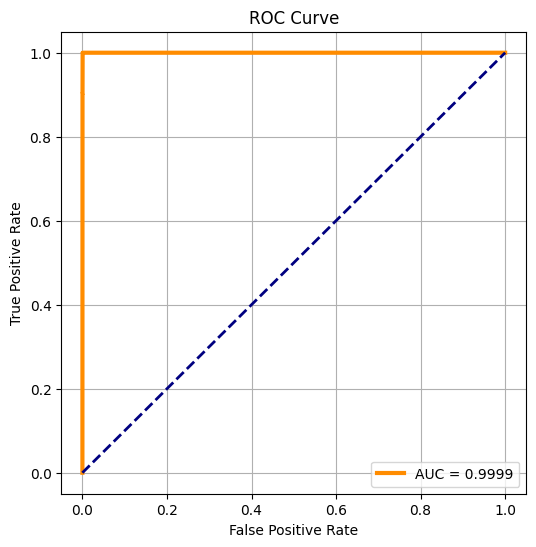

Precision-Recall plot saved at: /content/drive/MyDrive/Fraud_Detection_Project/precision_recall_vs_threshold.png
ROC curve plot saved at: /content/drive/MyDrive/Fraud_Detection_Project/roc_curve.png


<Figure size 640x480 with 0 Axes>

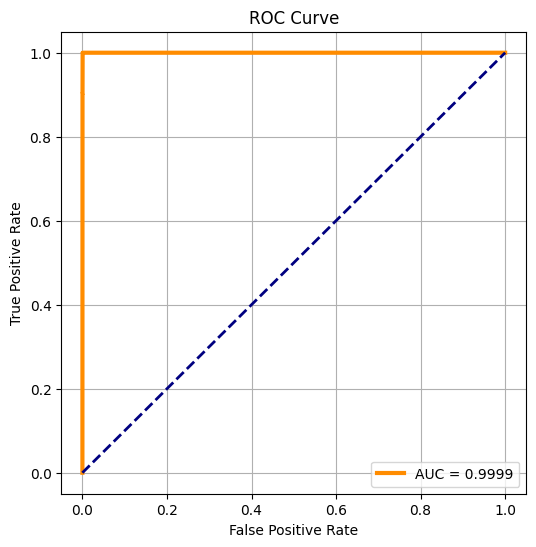

In [26]:

# POST-TRAINING EVALUATION & PLOTS

import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_curve, auc
import numpy as np
import os

# Predict probabilities
y_pred_prob = model.predict(X_test_scaled)

# Thresholds to test
thresholds = [0.3, 0.5, 0.7, 0.9]

print("=== METRICS AT DIFFERENT THRESHOLDS ===")
for t in thresholds:
    y_pred = (y_pred_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))


# Precision-Recall vs Threshold

recalls = []
precisions = []
for t in np.arange(0, 1.01, 0.01):
    y_pred = (y_pred_prob > t).astype(int)
    recalls.append(recall_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(np.arange(0, 1.01, 0.01), recalls, label="Recall")
plt.plot(np.arange(0, 1.01, 0.01), precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()


# ROC Curve + AUC

fpr, tpr, roc_thresh = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color='darkorange', lw=3)
plt.plot([0,1], [0,1], linestyle='--', color='navy', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()


# Save Plots to Drive
plot_path1 = os.path.join(project_path, "precision_recall_vs_threshold.png")
plt.savefig(plot_path1)
print("Precision-Recall plot saved at:", plot_path1)

plot_path2 = os.path.join(project_path, "roc_curve.png")
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color='darkorange', lw=3)
plt.plot([0,1], [0,1], linestyle='--', color='navy', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.savefig(plot_path2)
print("ROC curve plot saved at:", plot_path2)

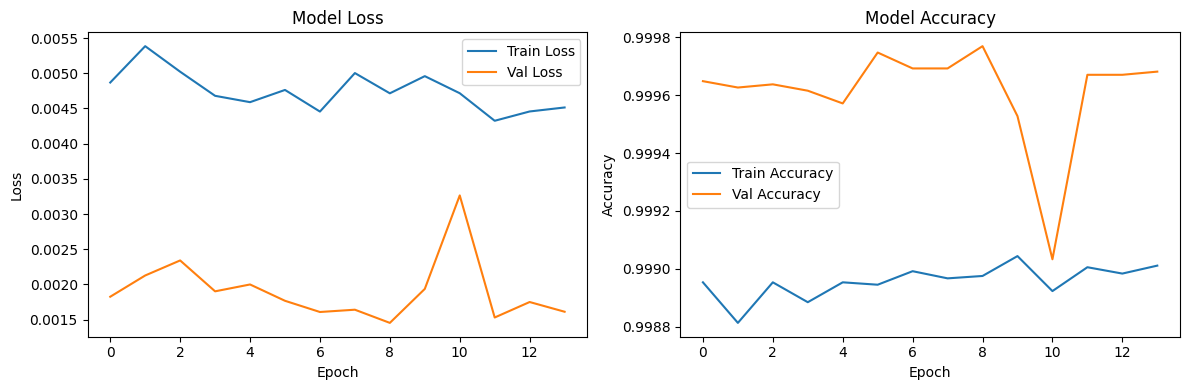

In [23]:

# STEP 9: PLOT TRAINING HISTORY


plt.figure(figsize=(12, 4))

# ---- LOSS PLOT ----
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# ---- ACCURACY PLOT ----
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
plot_path = os.path.join(project_path, "training_history.png")
plt.savefig(plot_path)
print("Plot saved at:", plot_path)

Plot saved at: /content/drive/MyDrive/Fraud_Detection_Project/training_history.png


<Figure size 640x480 with 0 Axes>

In [27]:
model_path = os.path.join(project_path, "fraud_detection_nn.h5")
model.save(model_path)

scaler_path = os.path.join(project_path, "scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
